## Overview

**Data Preparation**:
1. Review key findings
2. Build a Data Quality Plan
3. Implement fixes (drop, correct, clamp, impute)
4. Validate and save clean data



Import Required Libraries and Load Data

In [625]:
# Import required libraries for data quality analysis

import pandas as pd      # For data frame manipulation and CSV reading
import numpy as np       # For numerical computations
import matplotlib.pyplot as plt  # For creating visualizations
import re                # For address extraction

# Display plots inline in the notebook
%matplotlib inline

### Detailed Data Quality Plan

Based on the findings, here is our comprehensive plan for handling each feature:

### A comprehension of data issues


| Feature | Type | Data Quality Issue(s) | Impact | Root Cause Analysis | Proposed Solution | Final Action |
|---------|------|----------------------|--------|-------------------|------------------|--------------|
| **DateofSale(dd/mm/yyyy)** | object | Too much cardinality, not useful for prediction.| High | Natuaral records of dates| Extract year and month  |  Drop the original column and extract year and month from it. |
| **Address** | object | Too much cardinality, not useful for prediction. | High | Natuaral records of different properties | Investigate weather it can be converted to eircode. If not, drop it. | Drop the original column and extract area|
| **County** | category | No issue | Low | No issue | Keep  | Keep  |
| **Eircode** | object | Too much cardinality, not useful for prediction. | High | Natuaral records of different properties | Try to fill it by address and extract the district from eircode. If can't, drop it.  | Drop  |
| **Eircode** | object | Too much missing(68.86%), not useful for prediction.  | High | Data not collected | Try to fill it by address. If can't, drop it.  | Drop  |
| **Price** | float64 | Outliers and extremes | Medium | Most high values are valid outliers but several extremes need more investigation| Clamp the price to upper bound |Pick out and drop the bulk property transactions according to addresses , and clamp the prices of houses exceeding the upper bound to the upper bound.|
| **NotFullMarketPrice** | category | No issue | Low | Binary categorical feature | Keep | Keep |
| **VATExclusive** | category | No issue | Low | Binary categorical feature | Keep | Keep |
| **DescriptionofProperty** | category | No issue | Low | Records of property types | Keep | Keep |
| **PropertySizeDescription** | category | Too much missing(97.73%), not useful for prediction. | High | Data not collected | Drop the feature | Drop |
| **Other** | none | 4 duplicate rows | low | recording error | Remove duplicate rows | Remove |

**Summary of Actions:**
- **DROP 3 features**: Eircode(68.86% missing), PropertySizeDescription, Datetime(Extract Year and Month from it)
- **DROP 4 row**: 4 duplicate rows
- **TRANSFORM 1 feature**: Applied log transformation to `Price (€)` by creating a new feature `log_price`
- **Add 2 features**: saleYear, saleMonth
- **EXTRACT 1 feature**: Created `Region` by extracting Dublin district information from Address using regex patterns (e.g., D1, Dublin 2), with default categories for non-Dublin and unmatched cases

## Section 1: Implementation of Data Quality Strategies

In [626]:
# Load the dataset of DQR from CSV file
# Parameters:
#   - keep_default_na=True: Treat standard NaN representations as missing (not as text)
#   - delimiter=',': CSV file uses comma as delimiter  
#   - skipinitialspace=True: Remove leading whitespace after delimiter for cleaner column names
df = pd.read_csv('ppr-group-25204989-train-v1.csv', keep_default_na=True, delimiter=',', skipinitialspace=True)

# Configure pandas display options for better readability
pd.set_option('display.max_rows', 100)  # Show up to 100 rows in output

# Display the first 5 rows to inspect the data structure
df.head(5)

,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description
0,04/07/2016,"9 AL UISCE, ENNISCORTHY, CO WEXFORD",Wexford,NaN,62500.0,No,No,Second-Hand Dwelling house /Apartment,NaN
1,21/12/2016,"2 BEECHVILLE, THE LOUTH, CORK",Cork,NaN,150000.0,Yes,No,Second-Hand Dwelling house /Apartment,NaN
2,23/08/2016,"75 BELLEFIELD RD, ENNISCORTHY, WEXFORD",Wexford,NaN,94000.0,No,No,Second-Hand Dwelling house /Apartment,NaN
3,23/02/2016,"No. 6, St. Caillins View, Fenagh",Leitrim,NaN,149500.0,No,Yes,New Dwelling house /Apartment,greater than 125 sq metres
4,07/10/2016,"NO7 GRATTAN PARK, CONVENT RD, CLAREMORRIS",Mayo,NaN,170000.0,No,No,Second-Hand Dwelling house /Apartment,NaN


In [627]:
# check data types of each column
print(df.dtypes)

Date of Sale (dd/mm/yyyy)     object
Address                       object
County                        object
Eircode                       object
Price (€)                    float64
Not Full Market Price         object
VAT Exclusive                 object
Description of Property       object
Property Size Description     object
dtype: object


Since CSV files do not preserve pandas dtype information, any type conversions performed during the DQR stage are not retained when the dataset is reloaded.
Therefore, in the DQP stage, we explicitly re-cast the relevant columns (e.g., categorical and date features) to their intended data types before proceeding with further processing.

In [628]:
# Convert all object columns to categorical
for col in df.select_dtypes('object').columns:
    df[col] = df[col].astype('category')

# Change type of "Date of Sale (dd/mm/yyyy)" and "Address" 
df['Address']=df['Address'].astype('object')
df['Date of Sale (dd/mm/yyyy)']=df['Date of Sale (dd/mm/yyyy)'].astype('object')
df['Eircode']=df['Eircode'].astype('object')


numeric_columns = df.select_dtypes(['int64', 'float64']).columns
category_columns = df.select_dtypes('category').columns
object_columns=df.select_dtypes('object').columns

# Summary: Show feature categorization results
print("="*70)
print("FEATURE TYPES CONFIGURED FOR DATA QUALITY ASSESSMENT")
print("="*70)
print(f"\n✓ Numeric features ({len(numeric_columns)}):")
print(f"   {list(numeric_columns)}")
print(f"\n✓ Categorical features ({len(category_columns)}):")
print(f"   {list(category_columns)}")
print(f"\n✓ object features({len(object_columns)})")
print(f"   {list(object_columns)}")
print("\n" + "="*70)

FEATURE TYPES CONFIGURED FOR DATA QUALITY ASSESSMENT

✓ Numeric features (1):
   ['Price (€)']

✓ Categorical features (5):
   ['County', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description']

✓ object features(3)
   ['Date of Sale (dd/mm/yyyy)', 'Address', 'Eircode']



### Step 1: Create a backup of the original data from DQR
This allows us to compare and validate our transformations later

In [629]:
df_raw = df.copy()

print("="*70)
print("BACKUP CREATED")
print("="*70)
print(f"Original dataset preserved with shape: {df_raw.shape}")
print(f"Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}")
print(f"Columns: {list(df_raw.columns)}")
print("="*70)

BACKUP CREATED
Original dataset preserved with shape: (54000, 9)
Rows: 54000, Columns: 9
Columns: ['Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode', 'Price (€)', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description']


### Step 2: Investigate and Drop Problematic Features

We verify the two problematic features identified in DQR, then drop them in one step.
The code below documents the checks and the final drop operation.

In [630]:
# Step 2a: Verify the problematic features exist and analyse them before dropping
print("Analysis of Features to Drop:")
print("-" * 70)


# Analyze Eircode
print("\n1. Eircode - Missing Data Check:")
zeros_count = (df['Eircode'] == 0).sum()
missing_count = df['Eircode'].isnull().sum()
total_problematic = zeros_count + missing_count
pct_problematic = 100 * total_problematic / len(df)
print(f"   Number of zeros: {zeros_count}")
print(f"   Number of NaN: {missing_count}")
print(f"   Total problematic values: {total_problematic} ({pct_problematic:.1f}%)")
print("   → Decision: TOO MANY MISSING VALUES - DROP")

# Analyze Property Size Description
print("\n2. Property Size Description - Missing Data check:")
missing_count = df['Property Size Description'].isnull().sum()
pct_missing = 100 * missing_count / len(df)
print(f"   Number of missing values: {missing_count} ({pct_missing:.1f}%)")
print(f"   Non-missing value counts:")
print(f"   {df['Property Size Description'].value_counts(dropna=False)}")
print("   → Decision: EXCESSIVE MISSING DATA - DROP")

print("\n" + "="*70)
print("DROPPING FEATURES")
print("="*70)

# Drop the problematic columns
features_to_drop = ['Eircode', 'Property Size Description']
df = df.drop(features_to_drop, axis=1)

print(f"\n✓ Successfully dropped {len(features_to_drop)} features:")
for feat in features_to_drop:
    print(f"  - {feat}")
print(f"\nDataset shape after dropping features: {df.shape}")
print(f"Remaining columns ({df.shape[1]}): {list(df.columns)}")

Analysis of Features to Drop:
----------------------------------------------------------------------

1. Eircode - Missing Data Check:
   Number of zeros: 0
   Number of NaN: 37183
   Total problematic values: 37183 (68.9%)
   → Decision: TOO MANY MISSING VALUES - DROP

2. Property Size Description - Missing Data check:
   Number of missing values: 51152 (94.7%)
   Non-missing value counts:
   Property Size Description
NaN                                                                  51152
greater than or equal to 38 sq metres and less than 125 sq metres     2073
greater than or equal to 125 sq metres                                 537
less than 38 sq metres                                                 133
greater than 125 sq metres                                             105
Name: count, dtype: int64
   → Decision: EXCESSIVE MISSING DATA - DROP

DROPPING FEATURES

✓ Successfully dropped 2 features:
  - Eircode
  - Property Size Description

Dataset shape after dropping feat

### Step 3: Investigate and Remove duplicate rows

From the DQR analysis, we identified that there are duplicate records in the dataset.
Therefore, we investigate the presence of duplicates and remove them if confirmed.

In [631]:
print("="*70)
print("Investigation 1: Investigate Duplicate Rows")
print("="*70)

# Count duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows detected: {duplicate_count}")

if duplicate_count > 0:
    print("\nDuplicate rows found. Displaying duplicate entries:")
    display(df[df.duplicated(keep=False)])
else:
    print("\nNo duplicate rows found.")

Investigation 1: Investigate Duplicate Rows
Number of duplicate rows detected: 4

Duplicate rows found. Displaying duplicate entries:


,Date of Sale (dd/mm/yyyy),Address,County,Price (€),Not Full Market Price,VAT Exclusive,Description of Property
814,27/09/2016,"LISNANAGH, EDGEWORTHSTOWN, LONGFORD",Longford,140000.0,Yes,No,Second-Hand Dwelling house /Apartment
2752,27/09/2016,"LISNANAGH, EDGEWORTHSTOWN, LONGFORD",Longford,140000.0,Yes,No,Second-Hand Dwelling house /Apartment
7404,12/12/2017,"26 27 POPES QUAY, NORTH QUAY PLACE, CORK",Cork,135000.0,No,No,Second-Hand Dwelling house /Apartment
9273,12/12/2017,"26 27 POPES QUAY, NORTH QUAY PLACE, CORK",Cork,135000.0,No,No,Second-Hand Dwelling house /Apartment
21308,07/01/2019,"THE COACH HOUSE, CIRCULAR RD, DUNMORE EAST",Waterford,108333.0,Yes,No,Second-Hand Dwelling house /Apartment
23994,07/01/2019,"THE COACH HOUSE, CIRCULAR RD, DUNMORE EAST",Waterford,108333.0,Yes,No,Second-Hand Dwelling house /Apartment
48514,12/01/2024,"29 KING STREET, BELLTREE, CLONGRIFFIN",Dublin,570000.0,No,No,Second-Hand Dwelling house /Apartment
49945,12/01/2024,"29 KING STREET, BELLTREE, CLONGRIFFIN",Dublin,570000.0,No,No,Second-Hand Dwelling house /Apartment


In [632]:
# Remove duplicates
print("Removing rows with duplicates...")
print(f"Shape before dropping: {df.shape}")

# Get the indices of rows to drop
dup_all_idx = df[df.duplicated(keep=False)].index          
dup_drop_idx = df[df.duplicated()].index                  

print(f"Duplicate groups (all rows) indices: {list(dup_all_idx)}")
print(f"Indices to drop (keeping first occurrence): {list(dup_drop_idx)}")
print(f"Rows to drop: {len(dup_drop_idx)}")
df = df.drop(index=dup_drop_idx)

print(f"Shape after dropping: {df.shape}")
print(f"✓ Successfully removed {len(dup_drop_idx)} duplicate row(s)")

Removing rows with duplicates...
Shape before dropping: (54000, 7)
Duplicate groups (all rows) indices: [814, 2752, 7404, 9273, 21308, 23994, 48514, 49945]
Indices to drop (keeping first occurrence): [2752, 9273, 23994, 49945]
Rows to drop: 4
Shape after dropping: (53996, 7)
✓ Successfully removed 4 duplicate row(s)


### Step 4: Pick out and Drop the Bulk Property Transactions
According to the data understanding, the extreme outliers mainly comes from bulk property transactions. And the price of bulk property transaction could not be predicted using the same model as the normal transactions, and the extreme outliers would affect the model a lot. <br><br>
So we use regular expression to pick out bulk property transactions from addresses and drop them.

In [633]:
def is_bulk_sale(address):
    if not isinstance(address, str): return False
    addr = address.upper()

    # 1. Detects multiple units or house ranges (e.g., 'HOUSES', 'APARTMENTS', '1-10', '1 TO 5', '28 29 30').
    # These are definitive markers of bulk/portfolio transactions.
    pattern1 = r'BLOCKS|HOUSES|APARTMENTS|UNITS|\d+\s+TO\s+\d+|\d+-\d+|\d+\s+\d+'
    
    # 2. INSTITUTIONAL & LARGE-SCALE DEVELOPMENTS
    # Targets non-residential entities or macro-scale development projects 
    # (e.g., 'UNIVERSITY', 'CAMPUS') where sales involve entire buildings.
    pattern2 = r'CAMPUS|DEVELOPMENT|SCHEME|UNIVERSITY|COLLEGE|HOSPITAL'
    
    # 3. PROXY UNIT & BUILDING ANCHORS
    # Identifies cases where an entire block is registered under the first unit (e.g., 'APT 1')
    # or starts with 'BLOCK', a common indicator for multi-unit assets.
    pattern3 = r'^APT\s+1\b|^UNIT\s+1\b|^SUITE\s+1\b|^HOUSE\s+1\b|^BLOCK'

    # 4. LANDMARK HEADERS (BEFORE FIRST COMMA)
    # Identifies landmarks or estate names appearing before the first comma 
    # without a specific house number, typical for institutional acquisitions.
    pattern4 = r'^[^,]*(SQUARE|CROSS|MILLS)\b'

    if re.search(pattern1, addr): return True
    if re.search(pattern2, addr): return True
    if re.search(pattern3, addr): return True
    if re.search(pattern4, addr): return True
    
    return False

df['is_bulk'] = df['Address'].apply(is_bulk_sale)

df_bulk=df[df['is_bulk'] == True]
df_bulk['Price (€)'].describe()

count    1.337000e+03
mean     1.291859e+06
std      8.506680e+06
min      7.000000e+03
25%      1.500000e+05
50%      2.625550e+05
75%      4.260225e+05
max      2.219427e+08
Name: Price (€), dtype: float64

In [634]:
df = df.drop(df_bulk.index)
df.drop(columns=["is_bulk"], inplace=True)
df['Price (€)'].describe()

count    5.265900e+04
mean     3.057498e+05
std      3.545056e+05
min      5.250000e+03
25%      1.580000e+05
50%      2.500000e+05
75%      3.650000e+05
max      2.925000e+07
Name: Price (€), dtype: float64

<Axes: >

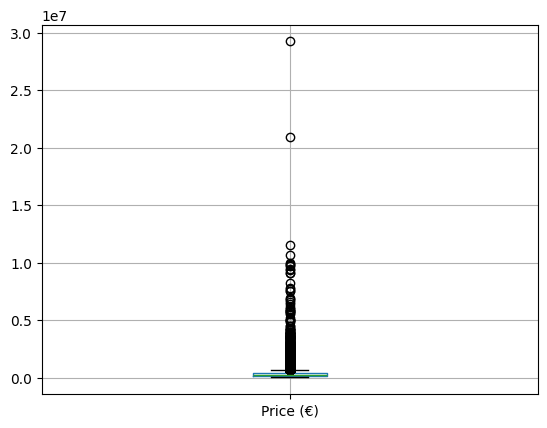

In [635]:
df.boxplot(column='Price (€)')

### Step 5: Handle Outliers - Clamp

After dropping the bulk transactions, there is still high outliers. These are prices of luxury mansion and would also affect the model severely. So we clamp the high outliers.

In [636]:
print("="*80)
print("Price Outliers")
print("="*80)

# calculate upper_bound and lower_bound
q1=df["Price (€)"].quantile(0.25)
q3=df["Price (€)"].quantile(0.75)
upper_bound = q3 + 1.5 * (q3-q1)
lower_bound=q1-1.5 * (q3-q1)
high_outliers_iqr = df[df["Price (€)"] > upper_bound]
low_outliers_iqr = df[df["Price (€)"] < lower_bound]

print(f"Upper bound: {upper_bound:,.2f}")
print(f"Lower bound: {lower_bound:,.2f}")

if len(high_outliers_iqr) > 0:
    outlier_idx = high_outliers_iqr.index
    print(f"Number of high outliers: {len(outlier_idx)}")
    display(high_outliers_iqr.head(5))
else:
    print("No high outliers detected.")

if len(low_outliers_iqr) > 0:
    outlier_idx = low_outliers_iqr.index
    print(f"Number of low outliers: {len(outlier_idx)}")
    display(low_outliers_iqr.head(5))
else:
    print("No low outliers detected.")

Price Outliers
Upper bound: 675,500.00
Lower bound: -152,500.00
Number of high outliers: 2803


,Date of Sale (dd/mm/yyyy),Address,County,Price (€),Not Full Market Price,VAT Exclusive,Description of Property
107,26/07/2016,"Ard Mor, 31 Granville Park, Blackrock",Dublin,991189.0,No,Yes,New Dwelling house /Apartment
110,23/12/2016,"31 GREEN ROAD, BLACKROCK, CO DUBLIN",Dublin,1025000.0,No,No,Second-Hand Dwelling house /Apartment
154,09/11/2016,"29 WOODLANDS PARK, BLACKROCK, DUBLIN",Dublin,2500000.0,No,No,Second-Hand Dwelling house /Apartment
193,25/11/2016,"28 PARKVALE, SANDYFORD ROAD, DUNDRUM",Dublin,740000.0,No,No,Second-Hand Dwelling house /Apartment
219,20/12/2016,"4 FARMLEIGH AVE, BLACKROCK, DUBLIN",Dublin,697500.0,No,No,Second-Hand Dwelling house /Apartment


No low outliers detected.


<Axes: >

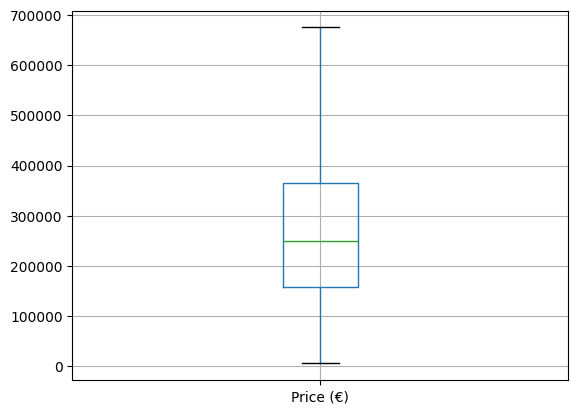

In [637]:
# Clamp the outliers
df['Price (€)'] = df['Price (€)'].clip(lower=lower_bound, upper=upper_bound)
df.boxplot(column='Price (€)')

array([[<Axes: title={'center': 'Price (€)'}>]], dtype=object)

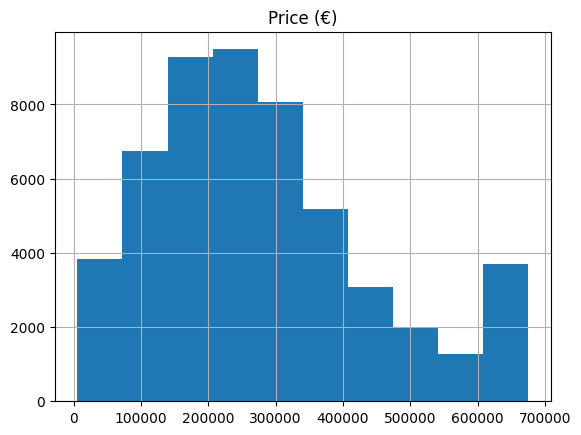

In [638]:
df.hist(column='Price (€)')

### Step 6: Feature Engineering


#### 1. Datetime extraction
The original date column exhibits very high cardinality, as each transaction is associated with a unique sale date. 
Such high-cardinality features are not directly useful for predictive modeling and may introduce noise. Therefore, we extract the year and month components to capture meaningful temporal patterns and remove the original date column.

In [639]:
# Convert to datetime (format: dd/mm/yyyy)
df["Date of Sale (dd/mm/yyyy)"] = pd.to_datetime(
    df["Date of Sale (dd/mm/yyyy)"],
    dayfirst=True,
    errors="coerce"
)

print("Date conversion completed.")

# Extract temporal features
df["SaleYear"] = df["Date of Sale (dd/mm/yyyy)"].dt.year
df["SaleMonth"] = df["Date of Sale (dd/mm/yyyy)"].dt.month

print("Year and Month extracted successfully.")

# Convert SaleMonth to categorical for better memory efficiency and analysis
df["SaleMonth"] = df["SaleMonth"].astype("category")


Date conversion completed.
Year and Month extracted successfully.


In [640]:
print("="*70)
print("Verification: Newly Created Temporal Features")
print("="*70)

# Preview new columns
print("\nPreview of SaleYear and SaleMonth:")
display(df[["SaleYear", "SaleMonth"]].head())

# Preview the full dataset to see new features in context
print("\nPreview of full dataset with new features:")
display(df.head(10))

# Check data types of relevant columns
print("\nData types of new features:")
print(df[["SaleYear", "SaleMonth"]].dtypes)

# Check value ranges
print("\nUnique SaleYear values:")
print(df["SaleYear"].unique())

print("\nUnique SaleMonth values:")
print(sorted(df["SaleMonth"].unique()))

Verification: Newly Created Temporal Features

Preview of SaleYear and SaleMonth:


,SaleYear,SaleMonth
0,2016,7
1,2016,12
2,2016,8
3,2016,2
4,2016,10



Preview of full dataset with new features:


,Date of Sale (dd/mm/yyyy),Address,County,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,SaleYear,SaleMonth
0,2016-07-04,"9 AL UISCE, ENNISCORTHY, CO WEXFORD",Wexford,62500.0,No,No,Second-Hand Dwelling house /Apartment,2016,7
1,2016-12-21,"2 BEECHVILLE, THE LOUTH, CORK",Cork,150000.0,Yes,No,Second-Hand Dwelling house /Apartment,2016,12
2,2016-08-23,"75 BELLEFIELD RD, ENNISCORTHY, WEXFORD",Wexford,94000.0,No,No,Second-Hand Dwelling house /Apartment,2016,8
3,2016-02-23,"No. 6, St. Caillins View, Fenagh",Leitrim,149500.0,No,Yes,New Dwelling house /Apartment,2016,2
4,2016-10-07,"NO7 GRATTAN PARK, CONVENT RD, CLAREMORRIS",Mayo,170000.0,No,No,Second-Hand Dwelling house /Apartment,2016,10
5,2016-12-16,"MAUMEEN, LETTERMORE, COUNTY GALWAY",Galway,50000.0,No,No,Second-Hand Dwelling house /Apartment,2016,12
7,2016-10-28,"10 MILLMOUNT TERRACE, DUNDRUM RD, MILLTOWN DUB...",Dublin,15000.0,No,No,Second-Hand Dwelling house /Apartment,2016,10
8,2016-08-11,"29 CLODAGH RD, AVONDALE, WATERFORD",Waterford,160000.0,No,No,Second-Hand Dwelling house /Apartment,2016,8
9,2016-12-23,"8 The Schoolyard, Castlecomer Road, Kilkenny",Kilkenny,320000.0,No,Yes,New Dwelling house /Apartment,2016,12
11,2016-05-18,"18 BEECHFIELD HAVEN, CORBAWN LANE, SHANKILL",Dublin,225000.0,No,No,Second-Hand Dwelling house /Apartment,2016,5



Data types of new features:
SaleYear        int32
SaleMonth    category
dtype: object

Unique SaleYear values:
[2016 2017 2018 2019 2020 2021 2022 2023 2024]

Unique SaleMonth values:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [641]:
# Drop the original date column as it's no longer needed
df.drop(columns=["Date of Sale (dd/mm/yyyy)"], inplace=True)
print("Original date column removed.")

Original date column removed.


#### 2. Address extraction
The original date column exhibits very high cardinality, as each transaction is associated with a specific adderss. 
Such high-cardinality features are not directly useful for predictive modeling and may introduce noise. Therefore, we extract region words to capature useful information.

In [642]:

# set the default value as NON_DUBLIN
df['Region'] = 'NON_DUBLIN'

# define the pattern for matching "Dublin ##""D##" and "Dublin"
pattern = r'\b(DUBLIN\s*\d+|D\d+[A-Z]?|DUBLIN)\b'

# select the rows whose county is Dublin and extract districts from addresses
is_dublin_county = df['County'].str.contains('Dublin', case=False, na=False)
extracted = df.loc[is_dublin_county, 'Address'].astype(str).str.extract(pattern, flags=re.IGNORECASE, expand=True)[0]
extracted = extracted.str.upper().str.replace(' ', '', regex=False)
extracted = extracted.replace('DUBLIN', 'DUBLIN_OTHER')
df['Region'] = extracted

# if no result but the county is dublin, fill it as DUBLIN_OTHER
df.loc[(df['Region'].isna()) & (df['County'].str.contains('Dublin', case=False, na=False)), 'Region'] = 'DUBLIN_OTHER'

df.loc[is_dublin_county, 'Region'] = extracted

df.loc[is_dublin_county & df['Region'].isna(), 'Region'] = 'DUBLIN_OTHER'

df['Region'] = df['Region'].fillna('NON_DUBLIN')

print(df['Region'].value_counts())


Region
NON_DUBLIN      36536
DUBLIN_OTHER     7734
DUBLIN15          947
DUBLIN8           567
DUBLIN7           539
DUBLIN12          520
DUBLIN24          511
DUBLIN4           506
DUBLIN9           497
DUBLIN18          479
DUBLIN3           426
DUBLIN11          424
DUBLIN14          409
DUBLIN16          409
DUBLIN6           380
DUBLIN5           359
DUBLIN13          326
DUBLIN22          293
DUBLIN1           293
DUBLIN2           185
DUBLIN10          145
DUBLIN20           92
DUBLIN17           79
DUBLIN07            1
D1                  1
DUBLIN19            1
Name: count, dtype: int64


In [643]:
df['Region']=df['Region'].replace('DUBLIN07','DUBLIN7')
df['Region']=df['Region'].replace('D1','DUBLIN1')

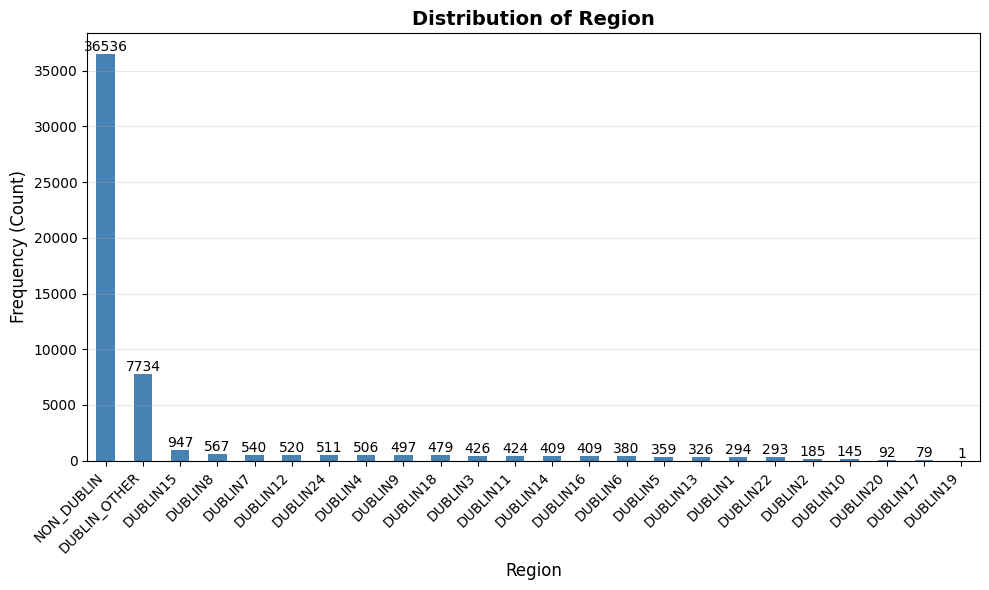

In [644]:
df['Region']=df['Region'].astype('category')

plt.figure(figsize=(10, 6))
ax = df['Region'].value_counts(dropna=False).plot(kind='bar', color='steelblue')
plt.title('Distribution of Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

In [645]:
# Drop the original date column as it's no longer needed
df.drop(columns=["Address"], inplace=True)
print("Original date column removed.")

Original date column removed.


In [646]:
# Standarlize feature names
df.columns = df.columns.str.replace(' ', '')


## Section 2: Validation & Summary

### Step 7: Validate Cleaned Dataset

After implementing all data quality strategies, we validate that:
1. All identified issues have been resolved
2. No new issues were introduced during cleaning
3. Data types are correct
4. No remaining missing values (except where appropriate)
5. Dataset is ready for modeling

In [647]:
print("="*70)
print("DATA QUALITY VALIDATION - FINAL CHECKS")
print("="*70)

# Comparison: Before vs After
print("\n1. DATASET DIMENSIONS COMPARISON")
print("-" * 70)
print(f"Original dataset:")
print(f"  Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}")
print(f"\nCleaned dataset:")
print(f"  Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nChanges:")
print(f"  Rows removed: {df_raw.shape[0] - df.shape[0]} (4 duplictate rows)")
print(f"  Columns dropped: {df_raw.shape[1] - df.shape[1]} (2 problematic features)")

# Check for missing values
print("\n2. MISSING VALUES CHECK")
print("-" * 70)
missing_summary = df.isnull().sum()
if missing_summary.sum() == 0:
    print("✓ All missing values processed successfully - NONE remaining")
else:
    print("⚠ WARNING: Remaining missing values found:")
    print(missing_summary[missing_summary > 0])

# Check data types
print("\n3. DATA TYPES CHECK")
print("-" * 70)
print("Remaining features and their types:")
df.info()


# Check for duplicates
print("\n4. DUPLICATE CHECK")
print("-" * 70)
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")
if dup_count == 0:
    print("✓ No duplicate rows found")
else:
    print(f"⚠ WARNING: {dup_count} duplicate rows detected")

print("\n" + "="*70)
print("VALIDATION COMPLETE")
print("="*70)

DATA QUALITY VALIDATION - FINAL CHECKS

1. DATASET DIMENSIONS COMPARISON
----------------------------------------------------------------------
Original dataset:
  Rows: 54000, Columns: 9

Cleaned dataset:
  Rows: 52659, Columns: 8

Changes:
  Rows removed: 1341 (4 duplictate rows)
  Columns dropped: 1 (2 problematic features)

2. MISSING VALUES CHECK
----------------------------------------------------------------------
✓ All missing values processed successfully - NONE remaining

3. DATA TYPES CHECK
----------------------------------------------------------------------
Remaining features and their types:
<class 'pandas.core.frame.DataFrame'>
Index: 52659 entries, 0 to 53999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   County                 52659 non-null  category
 1   Price(€)               52659 non-null  float64 
 2   NotFullMarketPrice     52659 non-null  category
 3   VATExclusive 

In [648]:
# Stats for numeric features.
df.describe(include=['int', 'float']).T
print(df.dtypes)

County                   category
Price(€)                  float64
NotFullMarketPrice       category
VATExclusive             category
DescriptionofProperty    category
SaleYear                    int32
SaleMonth                category
Region                   category
dtype: object


### Summary: Numeric and Categorical Features After Cleaning

In [649]:
# Stats for category features.
df.describe(include="category").T

,count,unique,top,freq
County,52659,26,Dublin,16123
NotFullMarketPrice,52659,2,No,49905
VATExclusive,52659,2,No,43275
DescriptionofProperty,52659,3,Second-Hand Dwelling house /Apartment,43123
SaleMonth,52659,12,12,6168
Region,52659,24,NON_DUBLIN,36536


In [650]:
df.nunique()

County                     26
Price(€)                 5762
NotFullMarketPrice          2
VATExclusive                2
DescriptionofProperty       3
SaleYear                    9
SaleMonth                  12
Region                     24
dtype: int64

In [651]:
df.isnull().sum()

County                   0
Price(€)                 0
NotFullMarketPrice       0
VATExclusive             0
DescriptionofProperty    0
SaleYear                 0
SaleMonth                0
Region                   0
dtype: int64

All features seem ok now, no missing values or strange values.

### Step 6: Save Cleaned Dataset
Save the new data frame to a file with a name that reflects that the data has been cleaned.

In [652]:
print("="*70)
print("SAVING CLEANED DATASET")
print("="*70)

# Define output filename with version indicator
output_filename = 'ppr-group-25204989-train-Cleaned.csv'

# Write the cleaned dataframe to a csv file with UTF-8 encoding
df.to_csv(output_filename, index=False, encoding='utf-8')

print(f"\n✓ Cleaned dataset saved successfully")
print(f"\nFile Information:")
print(f"  Filename: {output_filename}")
print(f"  Location: Current working directory")
print(f"  Format: CSV (UTF-8 encoding)")
print(f"  Rows: {df.shape[0]}")
print(f"  Columns: {df.shape[1]}")
print(f"\nDataset is now ready for:")
print(f"  - Data Exploration (relationships between features)")
print(f"  - Feature Engineering (creating derived features)")
print(f"  - Modeling (building predictive models)")
print("="*70)

SAVING CLEANED DATASET

✓ Cleaned dataset saved successfully

File Information:
  Filename: ppr-group-25204989-train-Cleaned.csv
  Location: Current working directory
  Format: CSV (UTF-8 encoding)
  Rows: 52659
  Columns: 8

Dataset is now ready for:
  - Data Exploration (relationships between features)
  - Feature Engineering (creating derived features)
  - Modeling (building predictive models)
